# Phase 4 — Training Strategy
### Facial Emotion Recognition — FER2013

**What we build here:**
1. Reproduce `FERModel` + `FERDataset` + DataLoaders from previous phases
2. Loss function: `CrossEntropyLoss` with class weights + label smoothing
3. Optimizer: `AdamW` with layer-wise LR via `get_param_groups()`
4. Scheduler: `OneCycleLR` (warmup → peak → cosine decay)
5. Mixed-precision training loop (`torch.amp`)
6. Per-epoch validation with macro-F1 as primary metric
7. Early stopping + best-checkpoint saving
8. Live training curve plots


## 1 — Imports & device

In [1]:
import os, pickle, time, math, warnings
from pathlib import Path
from collections import defaultdict
import random

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
import torchvision.models as models
from torchvision.models import EfficientNet_B2_Weights
from torch.amp import autocast, GradScaler
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from PIL import Image
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")
%matplotlib inline
plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.benchmark = True   # faster conv on fixed input size

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
if device.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")


Device : cuda
GPU    : NVIDIA A100-SXM4-80GB
VRAM   : 85.0 GB


## 2 — Rebuild components from Phases 2 & 3

We paste the essential classes here so Phase 4 is a self-contained notebook.  
In production you'd import from a `fer_utils.py` module instead.


In [2]:
# ── Load Phase 2 config ────────────────────────────────────────────────────────
with open("eda_outputs/data_pipeline_config.pkl", "rb") as f:
    cfg = pickle.load(f)

EMOTIONS    = cfg["EMOTIONS"]
NUM_CLASSES = cfg["NUM_CLASSES"]
LABEL2IDX   = cfg["LABEL2IDX"]
IDX2LABEL   = cfg["IDX2LABEL"]
DATASET_MEAN = cfg["DATASET_MEAN"]
DATASET_STD  = cfg["DATASET_STD"]
IMG_SIZE     = cfg["IMG_SIZE"]
BATCH_SIZE   = cfg["BATCH_SIZE"]
NUM_WORKERS  = cfg["NUM_WORKERS"]
TRAIN_COUNTS = cfg["TRAIN_COUNTS"]
DATASET_ROOT = Path(cfg["DATASET_ROOT"])

class_weights = torch.load("eda_outputs/class_weights.pt").to(device)

print(f"Dataset root : {DATASET_ROOT}")
print(f"Classes      : {NUM_CLASSES}  {EMOTIONS}")
print(f"Class weights: {class_weights.tolist()}")


Dataset root : /home/zainaandalhaq/Facial/fer2013_img
Classes      : 7  ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Class weights: [1.026669979095459, 9.397767066955566, 1.0010254383087158, 0.5684936046600342, 0.8260059952735901, 0.8491406440734863, 1.293238639831543]


In [3]:
# ── FERDataset (Phase 2) ───────────────────────────────────────────────────────
class FERDataset(Dataset):
    def __init__(self, root, split, transform=None):
        self.root = Path(root); self.split = split; self.transform = transform
        self.samples = []; self.class_counts = {}
        self._load()

    def _load(self):
        split_dir = self.root / self.split
        for emotion in EMOTIONS:
            ed = split_dir / emotion
            if not ed.exists(): continue
            imgs = list(ed.glob("*.jpg")) + list(ed.glob("*.jpeg")) + list(ed.glob("*.png"))
            lbl  = LABEL2IDX[emotion]
            for p in imgs: self.samples.append((p, lbl))
            self.class_counts[lbl] = len(imgs)
        random.shuffle(self.samples)

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        p, lbl = self.samples[idx]
        img = Image.open(p).convert("RGB")
        if self.transform: img = self.transform(img)
        return img, lbl

    def get_labels(self): return [l for _, l in self.samples]


# ── Transforms ─────────────────────────────────────────────────────────────────
normalize = T.Normalize(mean=DATASET_MEAN, std=DATASET_STD)
INTERP    = T.InterpolationMode.BICUBIC

train_transform = T.Compose([
    T.Resize((int(IMG_SIZE*1.12), int(IMG_SIZE*1.12)), interpolation=INTERP),
    T.RandomCrop(IMG_SIZE),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    T.RandomGrayscale(p=0.1),
    T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
    T.ToTensor(), normalize,
    T.RandomErasing(p=0.3, scale=(0.02, 0.12), ratio=(0.3, 3.3), value=0),
])
val_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE), interpolation=INTERP),
    T.ToTensor(), normalize,
])


# ── WeightedRandomSampler ──────────────────────────────────────────────────────
from collections import Counter

def make_sampler(dataset):
    labels = dataset.get_labels()
    counts = Counter(labels)
    n      = len(labels)
    wmap   = {c: n / cnt for c, cnt in counts.items()}
    sw     = torch.tensor([wmap[l] for l in labels], dtype=torch.float)
    return WeightedRandomSampler(sw, num_samples=n, replacement=True)


# ── DataLoaders ────────────────────────────────────────────────────────────────
available = [s for s in ["train", "val", "test"] if (DATASET_ROOT / s).exists()]
print(f"Available splits: {available}")

datasets, loaders = {}, {}
for split in available:
    tf = train_transform if split == "train" else val_transform
    ds = FERDataset(DATASET_ROOT, split, transform=tf)
    datasets[split] = ds
    sampler = make_sampler(ds) if split == "train" else None
    loaders[split] = DataLoader(
        ds, batch_size=BATCH_SIZE,
        sampler=sampler, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True,
        drop_last=(split == "train"),
    )
    print(f"  {split:>5}: {len(ds):>6,} samples → {len(loaders[split])} batches")


Available splits: ['train', 'val', 'test']
  train: 24,406 samples → 381 batches
    val:  4,303 samples → 68 batches
   test:  7,178 samples → 113 batches


In [4]:
# ── Model classes (Phase 3) ────────────────────────────────────────────────────

class ChannelAttention(nn.Module):

    def __init__(self, ch, r=16):
        super().__init__()

        mid = max(ch // r, 8)

        self.shared_mlp = nn.Sequential(

            nn.Linear(ch, mid, bias=False),

            nn.ReLU(inplace=True),

            nn.Linear(mid, ch, bias=False)
        )

    def forward(self, x):

        B, C, H, W = x.shape

        avg_pool = x.mean([2, 3])

        max_pool = x.amax([2, 3])

        attn = torch.sigmoid(

            self.shared_mlp(avg_pool) +

            self.shared_mlp(max_pool)
        )

        return x * attn.view(B, C, 1, 1)


class SpatialAttention(nn.Module):

    def __init__(self, k=7):
        super().__init__()

        self.conv = nn.Conv2d(
            2,
            1,
            kernel_size=k,
            padding=k // 2,
            bias=False
        )

    def forward(self, x):

        avg_map = x.mean(1, keepdim=True)

        max_map = x.amax(1, keepdim=True)

        attn = torch.cat(
            [avg_map, max_map],
            dim=1
        )

        attn = torch.sigmoid(
            self.conv(attn)
        )

        return x * attn


class CBAM(nn.Module):

    def __init__(self, ch, r=16, k=7):
        super().__init__()

        self.channel = ChannelAttention(ch, r)

        self.spatial = SpatialAttention(k)

    def forward(self, x):

        x = self.channel(x)

        x = self.spatial(x)

        return x


class FERHead(nn.Module):

    def __init__(
        self,
        in_f,
        num_classes=7,
        dropout1=0.4,
        dropout2=0.3
    ):
        super().__init__()

        self.head = nn.Sequential(

            nn.Linear(in_f, 512),

            nn.BatchNorm1d(512),

            nn.ReLU(inplace=True),

            nn.Dropout(dropout1),

            nn.Linear(512, 256),

            nn.BatchNorm1d(256),

            nn.ReLU(inplace=True),

            nn.Dropout(dropout2),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):

        return self.head(x)


class FERModel(nn.Module):

    BACKBONE_OUT = 1408

    def __init__(
        self,
        num_classes=7,
        pretrained=True,
        freeze_blocks=5,
        cbam_reduction=16,
        dropout1=0.4,
        dropout2=0.3
    ):
        super().__init__()

        bb = models.efficientnet_b2(
            weights=EfficientNet_B2_Weights.IMAGENET1K_V1
            if pretrained else None
        )

        self.features = bb.features

        self.avgpool = bb.avgpool

        # Freeze early backbone blocks
        for i, blk in enumerate(self.features):

            if i < freeze_blocks:

                for p in blk.parameters():

                    p.requires_grad = False

        # CBAM
        self.cbam = CBAM(
            self.BACKBONE_OUT,
            r=cbam_reduction
        )

        # Classification head
        self.classifier = FERHead(
            self.BACKBONE_OUT,
            num_classes=num_classes,
            dropout1=dropout1,
            dropout2=dropout2
        )

        self._init()

    def _init(self):

        for m in (

            list(self.cbam.modules()) +

            list(self.classifier.modules())

        ):

            if isinstance(m, nn.Linear):

                nn.init.kaiming_normal_(
                    m.weight,
                    mode="fan_out",
                    nonlinearity="relu"
                )

                if m.bias is not None:

                    nn.init.zeros_(m.bias)

            elif isinstance(
                m,
                (nn.BatchNorm1d, nn.BatchNorm2d)
            ):

                nn.init.ones_(m.weight)

                nn.init.zeros_(m.bias)

    def forward(self, x):

        x = self.features(x)

        x = self.cbam(x)

        x = self.avgpool(x)

        x = torch.flatten(x, 1)

        x = self.classifier(x)

        return x

    def get_param_groups(self, base_lr):

        return [

            {
                "params": [
                    p for p in self.features.parameters()
                    if p.requires_grad
                ],

                "lr": base_lr * 0.1,

                "name": "backbone"
            },

            {
                "params": self.cbam.parameters(),

                "lr": base_lr,

                "name": "cbam"
            },

            {
                "params": self.classifier.parameters(),

                "lr": base_lr,

                "name": "head"
            }
        ]


# ── Load from Phase 3 checkpoint ─────────────────────────────

ckpt = torch.load(
    "checkpoints/phase3_init.pt",
    map_location=device
)

model = FERModel(
    **ckpt["model_config"]
).to(device)

model.load_state_dict(
    ckpt["model_state"]
)

trainable = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    f"✓ FERModel loaded — {trainable:,} trainable parameters"
)

✓ FERModel loaded — 8,249,875 trainable parameters


## 3 — Training hyperparameters

In [5]:
# ── Core hypers ────────────────────────────────────────────────────────────────
NUM_EPOCHS      = 50
BASE_LR         = 3e-4          # head & CBAM LR; backbone gets BASE_LR * 0.1
WEIGHT_DECAY    = 1e-4
LABEL_SMOOTHING = 0.1           # reduces overconfidence; good for FER noise
GRAD_CLIP       = 1.0           # gradient norm clipping

# ── Scheduler ──────────────────────────────────────────────────────────────────
# OneCycleLR: linear warmup for pct_start fraction, then cosine decay
# Gives fast early learning without instability
PCT_START       = 0.1           # 10% of steps = warmup

# ── Early stopping ─────────────────────────────────────────────────────────────
PATIENCE        = 10            # stop if val macro-F1 doesn't improve for 10 epochs
MIN_DELTA       = 1e-4          # minimum improvement to count as progress

# ── Eval split: use val if available, else test ────────────────────────────────
EVAL_SPLIT = "val" if "val" in loaders else "test"
print(f"Eval split     : {EVAL_SPLIT}")
print(f"Epochs         : {NUM_EPOCHS}")
print(f"Base LR        : {BASE_LR}  (backbone: {BASE_LR*0.1})")
print(f"Weight decay   : {WEIGHT_DECAY}")
print(f"Label smoothing: {LABEL_SMOOTHING}")
print(f"Grad clip      : {GRAD_CLIP}")
print(f"Patience       : {PATIENCE} epochs")


Eval split     : val
Epochs         : 50
Base LR        : 0.0003  (backbone: 2.9999999999999997e-05)
Weight decay   : 0.0001
Label smoothing: 0.1
Grad clip      : 1.0
Patience       : 10 epochs


## 4 — Loss, optimizer & scheduler

**Why these choices:**

| Component | Choice | Reason |
|---|---|---|
| Loss | `CrossEntropyLoss` + class weights | Corrects 16.55x imbalance at gradient level |
| Label smoothing | 0.1 | FER2013 labels are noisy (~20% inter-annotator disagreement) |
| Optimizer | `AdamW` | Better weight decay decoupling than Adam; standard for fine-tuning |
| Scheduler | `OneCycleLR` | Warmup prevents early instability; cosine decay avoids sharp cutoff |
| AMP | `torch.amp` | ~2× speedup on A100 with bfloat16; no loss scaling needed |


In [6]:
# ── Loss ───────────────────────────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(
    weight          = class_weights,
    label_smoothing = LABEL_SMOOTHING,
)

# ── Optimizer: layer-wise LR via get_param_groups() ───────────────────────────
param_groups = model.get_param_groups(BASE_LR)
optimizer = torch.optim.AdamW(param_groups, weight_decay=WEIGHT_DECAY)

# ── Scheduler: OneCycleLR ──────────────────────────────────────────────────────
steps_per_epoch = len(loaders["train"])
total_steps     = NUM_EPOCHS * steps_per_epoch

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr      = [pg["lr"] for pg in param_groups],  # per-group max LR
    total_steps = total_steps,
    pct_start   = PCT_START,
    anneal_strategy = "cos",
    div_factor  = 25,       # initial_lr = max_lr / 25
    final_div_factor = 1e4, # final_lr   = initial_lr / 1e4
)

# ── AMP scaler (bfloat16 on A100 — no scaling needed) ─────────────────────────
use_amp = device.type == "cuda"
amp_dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
scaler  = GradScaler(enabled=(use_amp and amp_dtype == torch.float16))

print(f"✓ Criterion : CrossEntropyLoss (weighted + label_smoothing={LABEL_SMOOTHING})")
print(f"✓ Optimizer : AdamW  ({len(param_groups)} param groups)")
for pg in param_groups:
    n_p = sum(p.numel() for p in pg["params"])
    print(f"    {pg['name']:<18} lr={pg['lr']:.1e}  params={n_p:,}")
print(f"✓ Scheduler : OneCycleLR  ({total_steps} total steps)")
print(f"✓ AMP       : {use_amp}  dtype={amp_dtype}")


✓ Criterion : CrossEntropyLoss (weighted + label_smoothing=0.1)
✓ Optimizer : AdamW  (3 param groups)
    backbone           lr=1.2e-06  params=7,145,898
    cbam               lr=1.2e-05  params=247,906
    head               lr=1.2e-05  params=856,071
✓ Scheduler : OneCycleLR  (19050 total steps)
✓ AMP       : True  dtype=torch.bfloat16


## 5 — Evaluation function

We use **macro-F1** as the primary metric (not accuracy) because:
- Accuracy is dominated by `happy` (25% of test set)
- Macro-F1 weights all classes equally — critical with 16.55x imbalance
- A model predicting only "happy" would get ~25% accuracy but ~9% macro-F1


In [7]:
@torch.no_grad()
def evaluate(model, loader, criterion, split_name="eval"):
    """
    Returns dict with loss, accuracy, macro-F1, and per-class F1.
    """
    model.eval()
    total_loss, total_correct, total_samples = 0.0, 0, 0
    all_preds, all_labels = [], []

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        with autocast(device_type=device.type, dtype=amp_dtype, enabled=use_amp):
            logits = model(imgs)
            loss   = criterion(logits, labels)

        preds = logits.argmax(dim=1)
        total_loss    += loss.item() * labels.size(0)
        total_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)
        all_preds.extend(preds.cpu().tolist())
        all_labels.extend(labels.cpu().tolist())

    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    per_class_f1 = f1_score(all_labels, all_preds, average=None, zero_division=0)

    return {
        "loss"        : avg_loss,
        "accuracy"    : accuracy,
        "macro_f1"    : macro_f1,
        "per_class_f1": per_class_f1,
        "preds"       : all_preds,
        "labels"      : all_labels,
    }


# Quick sanity check with untrained model
print("── Pre-training eval sanity check ───────────────────────────")
_res = evaluate(model, loaders[EVAL_SPLIT], criterion, EVAL_SPLIT)
print(f"  Loss     : {_res['loss']:.4f}")
print(f"  Accuracy : {_res['accuracy']:.4f}  (random ≈ {1/NUM_CLASSES:.3f})")
print(f"  Macro-F1 : {_res['macro_f1']:.4f}  (random ≈ {1/NUM_CLASSES:.3f})")


── Pre-training eval sanity check ───────────────────────────
  Loss     : 4.4646
  Accuracy : 0.1838  (random ≈ 0.143)
  Macro-F1 : 0.1138  (random ≈ 0.143)


## 6 — Training loop

In [8]:
class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-4, mode="max"):
        self.patience  = patience
        self.min_delta = min_delta
        self.mode      = mode
        self.best      = -float("inf") if mode == "max" else float("inf")
        self.counter   = 0
        self.stopped   = False

    def step(self, metric) -> bool:
        improved = (metric > self.best + self.min_delta) if self.mode == "max"                    else (metric < self.best - self.min_delta)
        if improved:
            self.best    = metric
            self.counter = 0
            return True   # improved
        self.counter += 1
        if self.counter >= self.patience:
            self.stopped = True
        return False      # not improved


def train_one_epoch(model, loader, criterion, optimizer, scheduler, scaler, epoch):
    model.train()
    total_loss, total_correct, total_samples = 0.0, 0, 0

    pbar = tqdm(loader, desc=f"Epoch {epoch:03d} [train]", leave=False)
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast(device_type=device.type, dtype=amp_dtype, enabled=use_amp):
            logits = model(imgs)
            loss   = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        bs              = labels.size(0)
        total_loss     += loss.item() * bs
        total_correct  += (logits.argmax(1) == labels).sum().item()
        total_samples  += bs

        pbar.set_postfix(loss=f"{loss.item():.4f}",
                         acc=f"{total_correct/total_samples:.3f}",
                         lr=f"{scheduler.get_last_lr()[0]:.2e}")

    return {
        "loss"    : total_loss / total_samples,
        "accuracy": total_correct / total_samples,
    }


print("✓ Training utilities defined")


✓ Training utilities defined


## 7 — Run training

> This cell runs the full training loop. On the A100 expect ~8s/epoch → ~7 min total for 50 epochs.

In [9]:
os.makedirs("checkpoints", exist_ok=True)

history = defaultdict(list)   # {metric_name: [epoch_values]}
early_stop = EarlyStopping(patience=PATIENCE, min_delta=MIN_DELTA, mode="max")
best_macro_f1 = 0.0
best_epoch    = 0

print(f"Training FERModel for up to {NUM_EPOCHS} epochs")
print(f"Best checkpoint → checkpoints/best_model.pt")
print(f"Primary metric  → {EVAL_SPLIT} macro-F1\n")

t_start = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    # ── Train ──────────────────────────────────────────────────────────────
    train_metrics = train_one_epoch(
        model, loaders["train"], criterion, optimizer, scheduler, scaler, epoch
    )

    # ── Evaluate ───────────────────────────────────────────────────────────
    eval_metrics = evaluate(model, loaders[EVAL_SPLIT], criterion, EVAL_SPLIT)

    # ── Log ────────────────────────────────────────────────────────────────
    history["train_loss"].append(train_metrics["loss"])
    history["train_acc"].append(train_metrics["accuracy"])
    history["eval_loss"].append(eval_metrics["loss"])
    history["eval_acc"].append(eval_metrics["accuracy"])
    history["eval_macro_f1"].append(eval_metrics["macro_f1"])
    history["lr"].append(scheduler.get_last_lr()[0])

    improved = early_stop.step(eval_metrics["macro_f1"])

    # ── Save best checkpoint ───────────────────────────────────────────────
    if improved:
        best_macro_f1 = eval_metrics["macro_f1"]
        best_epoch    = epoch
        torch.save({
            "epoch"          : epoch,
            "model_state"    : model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "best_macro_f1"  : best_macro_f1,
            "history"        : dict(history),
            "model_config"   : ckpt["model_config"],
            "phase2_config"  : cfg,
        }, "checkpoints/best_model.pt")

    # ── Print ──────────────────────────────────────────────────────────────
    elapsed = time.time() - t_start
    marker  = " ✓ best" if improved else f"  (best: {best_macro_f1:.4f} @ ep{best_epoch})"
    print(
        f"Ep {epoch:03d}/{NUM_EPOCHS}  "
        f"train_loss={train_metrics['loss']:.4f}  train_acc={train_metrics['accuracy']:.4f}  "
        f"{EVAL_SPLIT}_loss={eval_metrics['loss']:.4f}  "
        f"{EVAL_SPLIT}_acc={eval_metrics['accuracy']:.4f}  "
        f"macro_f1={eval_metrics['macro_f1']:.4f}  "
        f"[{elapsed/60:.1f}m]{marker}"
    )

    if early_stop.stopped:
        print(f"\nEarly stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)")
        break

print(f"\n✓ Training complete")
print(f"  Best macro-F1 : {best_macro_f1:.4f}  (epoch {best_epoch})")
print(f"  Total time    : {(time.time()-t_start)/60:.1f} min")


Training FERModel for up to 50 epochs
Best checkpoint → checkpoints/best_model.pt
Primary metric  → val macro-F1



Epoch 001 [train]:   0%|          | 0/381 [00:00<?, ?it/s]

Ep 001/50  train_loss=10.4061  train_acc=0.1437  val_loss=5.1513  val_acc=0.1497  macro_f1=0.1330  [1.1m] ✓ best


Epoch 002 [train]:   0%|          | 0/381 [00:00<?, ?it/s]

Ep 002/50  train_loss=7.4286  train_acc=0.1687  val_loss=4.8568  val_acc=0.1308  macro_f1=0.1365  [2.2m] ✓ best


...

Ep 048/50  train_loss=0.7415  train_acc=0.7069  val_loss=1.4993  val_acc=0.6351  macro_f1=0.6108  [68.7m]  (best: 0.6214 @ ep40)


Epoch 049 [train]:   0%|          | 0/381 [00:00<?, ?it/s]

Ep 049/50  train_loss=0.7758  train_acc=0.7025  val_loss=1.4962  val_acc=0.6384  macro_f1=0.6176  [70.1m]  (best: 0.6214 @ ep40)


Epoch 050 [train]:   0%|          | 0/381 [00:00<?, ?it/s]

Ep 050/50  train_loss=0.7401  train_acc=0.7058  val_loss=1.4832  val_acc=0.6416  macro_f1=0.6149  [71.5m]  (best: 0.6214 @ ep40)

Early stopping at epoch 50 (no improvement for 10 epochs)

✓ Training complete
  Best macro-F1 : 0.6214  (epoch 40)
  Total time    : 71.5 min


## 8 — Training curves

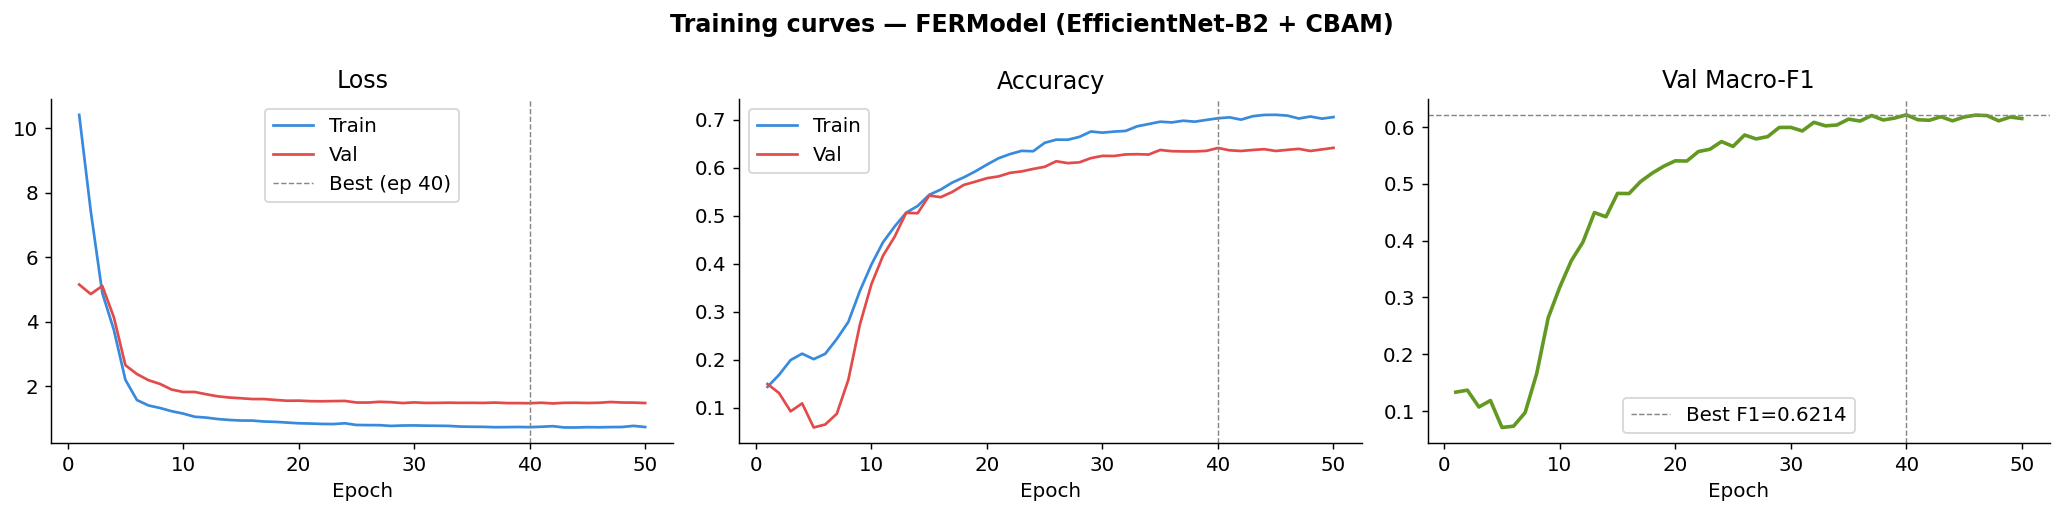

✓ Saved training_curves.png


In [10]:
epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss
axes[0].plot(epochs, history["train_loss"], label="Train", color="#378ADD")
axes[0].plot(epochs, history["eval_loss"],  label=EVAL_SPLIT.capitalize(), color="#E24B4A")
axes[0].axvline(best_epoch, color="#888780", linestyle="--", linewidth=0.8, label=f"Best (ep {best_epoch})")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

# Accuracy
axes[1].plot(epochs, history["train_acc"], label="Train",  color="#378ADD")
axes[1].plot(epochs, history["eval_acc"],  label=EVAL_SPLIT.capitalize(), color="#E24B4A")
axes[1].axvline(best_epoch, color="#888780", linestyle="--", linewidth=0.8)
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()

# Macro-F1
axes[2].plot(epochs, history["eval_macro_f1"], color="#639922", linewidth=2)
axes[2].axhline(best_macro_f1, color="#888780", linestyle="--", linewidth=0.8,
                label=f"Best F1={best_macro_f1:.4f}")
axes[2].axvline(best_epoch, color="#888780", linestyle="--", linewidth=0.8)
axes[2].set_title(f"{EVAL_SPLIT.capitalize()} Macro-F1")
axes[2].set_xlabel("Epoch"); axes[2].legend()

plt.suptitle("Training curves — FERModel (EfficientNet-B2 + CBAM)", fontweight="bold")
plt.tight_layout()
plt.savefig("eda_outputs/training_curves.png", bbox_inches="tight")
plt.show()
print("✓ Saved training_curves.png")


## 9 — Final evaluation on test set

Load the best checkpoint and evaluate on the held-out test set.

In [11]:
# Load best checkpoint
best_ckpt = torch.load("checkpoints/best_model.pt", map_location=device)
model.load_state_dict(best_ckpt["model_state"])
print(f"Loaded best checkpoint (epoch {best_ckpt['epoch']}, "
      f"macro-F1={best_ckpt['best_macro_f1']:.4f})")

# Evaluate on test
eval_split = "test" if "test" in loaders else EVAL_SPLIT
test_res   = evaluate(model, loaders[eval_split], criterion, eval_split)

print(f"\n── Test set results ──────────────────────────────────────────")
print(f"  Loss     : {test_res['loss']:.4f}")
print(f"  Accuracy : {test_res['accuracy']:.4f}  ({100*test_res['accuracy']:.2f}%)")
print(f"  Macro-F1 : {test_res['macro_f1']:.4f}")
print()
print("── Per-class F1 ──────────────────────────────────────────────")
for i, emotion in enumerate(EMOTIONS):
    f1  = test_res["per_class_f1"][i]
    bar = "█" * int(f1 * 30)
    print(f"  {emotion:<12} F1={f1:.4f}  {bar}")


Loaded best checkpoint (epoch 40, macro-F1=0.6214)

── Test set results ──────────────────────────────────────────
  Loss     : 1.4960
  Accuracy : 0.6385  (63.85%)
  Macro-F1 : 0.6170

── Per-class F1 ──────────────────────────────────────────────
  angry        F1=0.5656  ████████████████
  disgust      F1=0.5929  █████████████████
  fear         F1=0.4576  █████████████
  happy        F1=0.8482  █████████████████████████
  neutral      F1=0.6054  ██████████████████
  sad          F1=0.4856  ██████████████
  surprise     F1=0.7639  ██████████████████████


## 10 — Confusion matrix

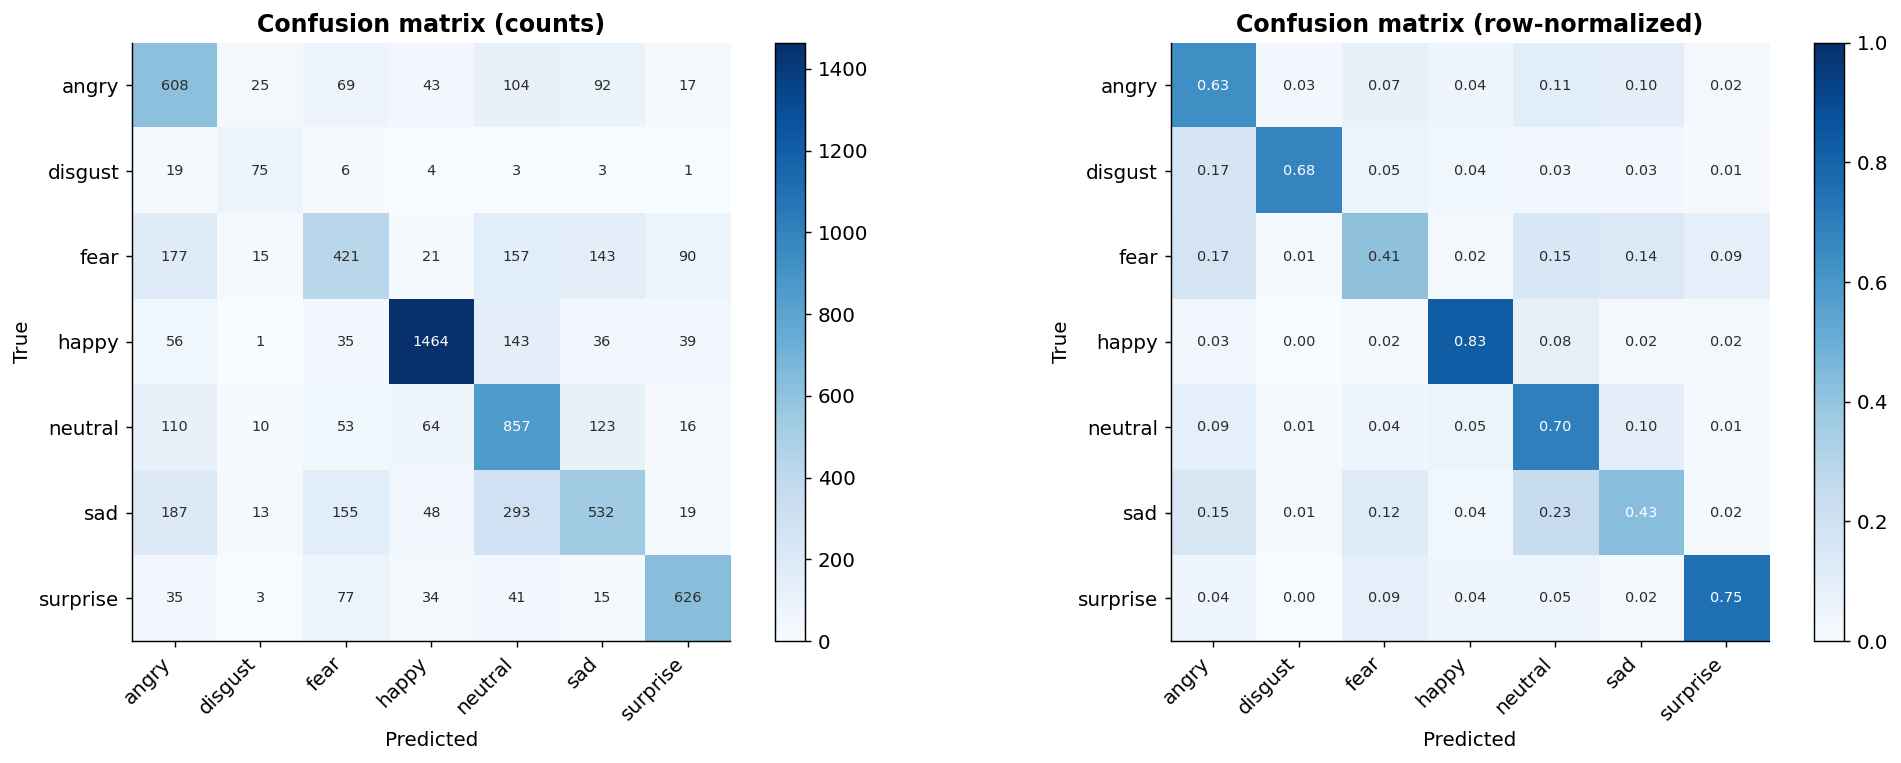

✓ Saved confusion_matrix.png


In [12]:
PALETTE = {
    "angry":"#E24B4A","disgust":"#639922","fear":"#7F77DD",
    "happy":"#EF9F27","neutral":"#888780","sad":"#378ADD","surprise":"#D4537E",
}

cm = confusion_matrix(test_res["labels"], test_res["preds"])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)  # row-normalize

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, data, title, fmt in [
    (axes[0], cm,      "Confusion matrix (counts)",      "d"),
    (axes[1], cm_norm, "Confusion matrix (row-normalized)", ".2f"),
]:
    im = ax.imshow(data, cmap="Blues", vmin=0,
                   vmax=data.max() if fmt == "d" else 1)
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(EMOTIONS, rotation=45, ha="right")
    ax.set_yticklabels(EMOTIONS)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title, fontweight="bold")
    plt.colorbar(im, ax=ax, fraction=0.046)
    thresh = data.max() / 2
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            val = f"{data[i,j]:{fmt}}"
            ax.text(j, i, val, ha="center", va="center", fontsize=8,
                    color="white" if data[i,j] > thresh else "#2C2C2A")

plt.tight_layout()
plt.savefig("eda_outputs/confusion_matrix.png", bbox_inches="tight")
plt.show()
print("✓ Saved confusion_matrix.png")


In [13]:
print(classification_report(
    test_res["labels"], test_res["preds"],
    target_names=EMOTIONS, digits=4
))


              precision    recall  f1-score   support

       angry     0.5101    0.6347    0.5656       958
     disgust     0.5282    0.6757    0.5929       111
        fear     0.5159    0.4111    0.4576      1024
       happy     0.8725    0.8253    0.8482      1774
     neutral     0.5363    0.6951    0.6054      1233
         sad     0.5636    0.4266    0.4856      1247
    surprise     0.7748    0.7533    0.7639       831

    accuracy                         0.6385      7178
   macro avg     0.6145    0.6317    0.6170      7178
weighted avg     0.6452    0.6385    0.6364      7178



## ✓ Phase 4 complete

| Artifact | Location |
|---|---|
| Best checkpoint | `checkpoints/best_model.pt` |
| Training curves | `eda_outputs/training_curves.png` |
| Confusion matrix | `eda_outputs/confusion_matrix.png` |

**Phase 5 will:**
- Load `best_model.pt`
- Deep-dive misclassification analysis (which pairs confuse the model)
- Per-class precision / recall breakdown
- Grad-CAM heatmaps on correctly and incorrectly classified samples
